# 03 — Pace and Strategy: Intra-Team Driver Comparison

**Primary question:** Which drivers adapted fastest to a regulation reset, and how does 2026 Year 1 compare to 2022 Year 1?

**Primary metric:** Qualifying gap between teammates (seconds and %)  
Same car, same weekend — eliminates machinery, strategy, traffic, and luck as variables.  
A smaller gap = closer teammates. Driver dominance = who outqualifies their teammate more often.

**Coverage:**
- 2022 Season (Year 1, Ground Effect era) — all rounds
- 2026 Season (Year 1, 2026 era) — completed rounds: Australia (R1), China (R2), Japan (R3)

Re-run as new 2026 rounds complete — data loaders are session-by-session.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from src.data.fastf1_loader import load_session, get_event_schedule
from src.analysis.intra_team import (
    prepare_quali_results,
    teammate_quali_gaps,
    season_teammate_gaps,
    mean_gap_by_constructor,
    driver_dominance,
)

print('Setup complete.')

Setup complete.


## Load Qualifying Data

Loads qualifying sessions for both seasons and normalises them to `[driver_abbr, team, best_q_s]` format.
FastF1 caches results locally — first run will be slow, subsequent runs read from cache.

In [2]:
def load_season_quali(year: int, rounds: list[int]) -> dict:
    """Load and normalise qualifying sessions for specified rounds of a season."""
    season_data = {}
    schedule = get_event_schedule(year)
    # Build round -> EventName lookup
    round_names = {
        int(row['RoundNumber']): row['EventName']
        for _, row in schedule.iterrows()
        if int(row['RoundNumber']) in rounds
    }
    for round_num in rounds:
        race_name = round_names.get(round_num, f'Round {round_num}')
        try:
            session = load_session(year, round_num, 'Q')
            quali_df = prepare_quali_results(session.results)
            season_data[(year, round_num, race_name)] = quali_df
            print(f'  {year} R{round_num:02d} {race_name}: {len(quali_df)} drivers')
        except Exception as e:
            print(f'  {year} R{round_num:02d} {race_name}: SKIPPED ({e})')
    return season_data

In [3]:
# 2022 season — all 22 rounds
print('Loading 2022 qualifying sessions...')
rounds_2022 = list(range(1, 23))
quali_2022 = load_season_quali(2022, rounds_2022)
print(f'Loaded {len(quali_2022)} rounds.')

core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Loading 2022 qualifying sessions...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '1', '55', '11', '44', '77', '20', '14', '63', '10', '31', '47', '4', '23', '24', '22', '27', '3', '18', '6']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


  2022 R01 Bahrain Grand Prix: 20 drivers


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['11', '16', '55', '1', '31', '63', '14', '77', '10', '20', '4', '3', '24', '47', '18', '44', '23', '27', '6', '22']
core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


...

  2022 R20 Mexico City Grand Prix: 20 drivers


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['20', '1', '63', '4', '55', '31', '14', '44', '11', '16', '23', '10', '5', '3', '18', '6', '24', '77', '22', '47']
core           INFO 	Loading data for Abu Dhabi Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


  2022 R21 São Paulo Grand Prix: 20 drivers


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '16', '55', '44', '63', '4', '31', '5', '3', '14', '22', '47', '18', '24', '20', '10', '77', '23', '6']


  2022 R22 Abu Dhabi Grand Prix: 20 drivers
Loaded 22 rounds.


In [4]:
# 2026 season — completed rounds only (re-run as season progresses)
# Bahrain (R4) and Saudi Arabia (R5) cancelled — regional conflict
print('Loading 2026 qualifying sessions...')
completed_2026 = [1, 2, 3]  # Australia, China, Japan
quali_2026 = load_season_quali(2026, completed_2026)
print(f'Loaded {len(quali_2026)} rounds.')

Loading 2026 qualifying sessions...


core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 18
core        WARNING 	No lap data for driver 55
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 18)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 55)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_c

  2026 R01 Australian Grand Prix: 22 drivers


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '63', '44', '16', '81', '1', '10', '3', '6', '87', '27', '43', '31', '30', '41', '5', '55', '23', '14', '77', '18', '11']
core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


  2026 R02 Chinese Grand Prix: 22 drivers


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '63', '81', '16', '1', '44', '10', '6', '5', '41', '3', '31', '27', '30', '43', '55', '23', '87', '11', '77', '14', '18']


  2026 R03 Japanese Grand Prix: 22 drivers
Loaded 3 rounds.


In [5]:
# Compute teammate gaps for both seasons
gaps_2022 = season_teammate_gaps(quali_2022)
gaps_2026 = season_teammate_gaps(quali_2026)

gaps_2022['era_year'] = 1  # Year 1 of Ground Effect era
gaps_2026['era_year'] = 1  # Year 1 of 2026 era

print(f'2022: {len(gaps_2022)} constructor-race pairs across {gaps_2022["round"].nunique()} rounds')
print(f'2026: {len(gaps_2026)} constructor-race pairs across {gaps_2026["round"].nunique()} rounds')

2022: 216 constructor-race pairs across 22 rounds
2026: 30 constructor-race pairs across 3 rounds


## 1. Mean Qualifying Gap by Constructor — 2022 Year 1

How close were teammates within each team across the full 2022 season?  
Sorted by mean gap ascending — closest pairs at the top.

In [6]:
mean_2022 = mean_gap_by_constructor(gaps_2022)
mean_2022['season'] = 2022
print(mean_2022.to_string(index=False))

    constructor  races  mean_gap_s  mean_gap_pct  season
       Mercedes     22       0.467        0.4971    2022
   Aston Martin     21       0.539        0.6167    2022
     AlphaTauri     21       0.681        0.8189    2022
        Ferrari     22       0.697        0.8402    2022
         Alpine     21       0.746        0.8049    2022
   Haas F1 Team     22       0.777        0.9204    2022
     Alfa Romeo     22       0.855        1.0042    2022
Red Bull Racing     22       1.049        1.2635    2022
       Williams     21       1.128        1.3537    2022
        McLaren     22       1.218        1.3886    2022


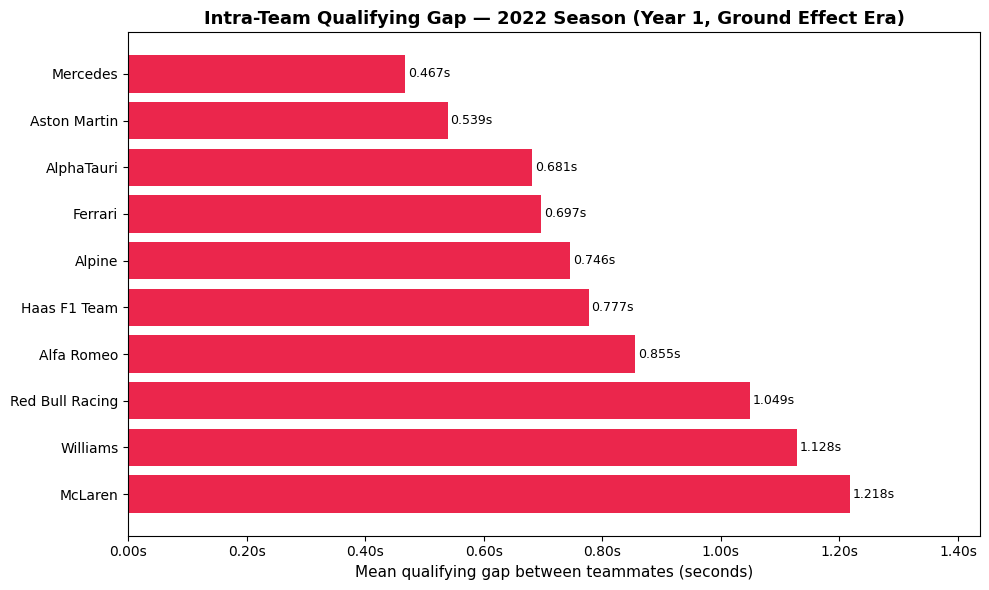

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
constructors = mean_2022['constructor'][::-1]
gaps = mean_2022['mean_gap_s'][::-1]

bars = ax.barh(constructors, gaps, color='#E8002D', alpha=0.85)
ax.set_xlabel('Mean qualifying gap between teammates (seconds)', fontsize=11)
ax.set_title('Intra-Team Qualifying Gap — 2022 Season (Year 1, Ground Effect Era)', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2fs'))

for bar, val in zip(bars, gaps):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}s', va='center', fontsize=9)

ax.set_xlim(0, gaps.max() * 1.18)
plt.tight_layout()
plt.show()

## 2. Driver Dominance — 2022 Year 1

How often did each driver outqualify their teammate?

In [8]:
MIN_RACES = 5  # Exclude replacement/one-off drivers; adjust as needed

dom_2022 = driver_dominance(gaps_2022, min_races=MIN_RACES)
dom_2022['season'] = 2022
print(dom_2022.to_string(index=False))

driver     constructor  total_races  faster_count  win_pct  season
   ALB        Williams           20            19     95.0    2022
   NOR         McLaren           22            20     90.9    2022
   VER Red Bull Racing           22            18     81.8    2022
   LEC         Ferrari           22            16     72.7    2022
   MAG    Haas F1 Team           22            16     72.7    2022
   ALO          Alpine           21            14     66.7    2022
   VET    Aston Martin           19            12     63.2    2022
   GAS      AlphaTauri           21            12     57.1    2022
   BOT      Alfa Romeo           22            12     54.5    2022
   HAM        Mercedes           22            12     54.5    2022
   ZHO      Alfa Romeo           22            10     45.5    2022
   RUS        Mercedes           22            10     45.5    2022
   TSU      AlphaTauri           21             9     42.9    2022
   STR    Aston Martin           21             8     38.1    

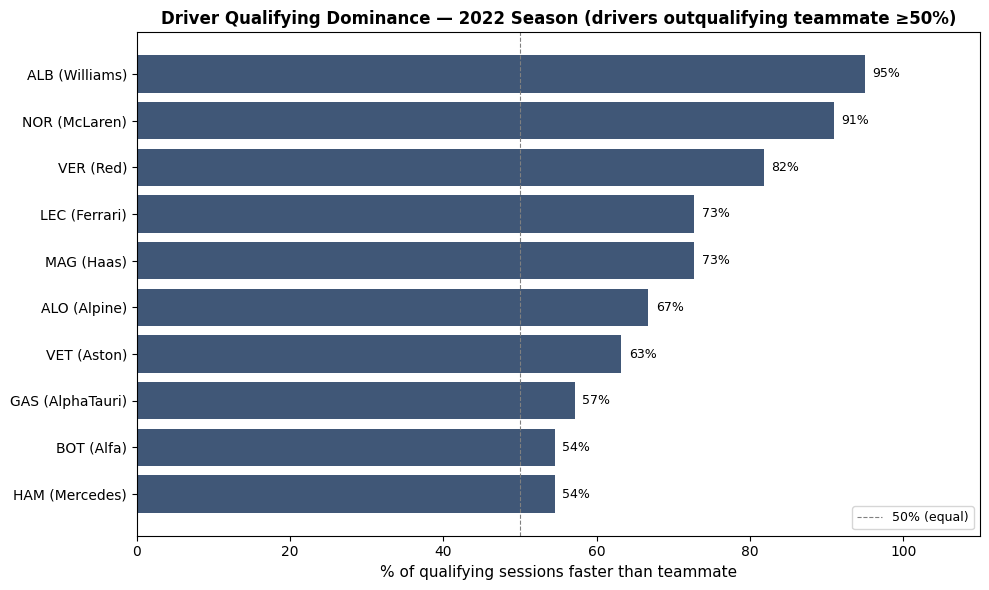

In [9]:
# Show only drivers with >50% win rate (clear dominance)
dominant_2022 = dom_2022[dom_2022['win_pct'] >= 50].copy()

fig, ax = plt.subplots(figsize=(10, 6))
labels = [f"{r['driver']} ({r['constructor'].split()[0]})" for _, r in dominant_2022.iterrows()]
labels_rev = labels[::-1]
pcts_rev = dominant_2022['win_pct'].values[::-1]

bars = ax.barh(labels_rev, pcts_rev, color='#1E3A5F', alpha=0.85)
ax.axvline(50, color='gray', linestyle='--', linewidth=0.8, label='50% (equal)')
ax.set_xlabel('% of qualifying sessions faster than teammate', fontsize=11)
ax.set_title('Driver Qualifying Dominance — 2022 Season (drivers outqualifying teammate ≥50%)', fontsize=12, fontweight='bold')
ax.set_xlim(0, 110)

for bar, val in zip(bars, pcts_rev):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}%', va='center', fontsize=9)

ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 3. Mean Qualifying Gap by Constructor — 2026 Year 1

Same metric, early 2026 data (3 rounds). Directional — will mature across the season.

In [10]:
mean_2026 = mean_gap_by_constructor(gaps_2026)
mean_2026['season'] = 2026
print(mean_2026.to_string(index=False))

    constructor  races  mean_gap_s  mean_gap_pct  season
        McLaren      3       0.143        0.1644    2026
        Ferrari      3       0.143        0.1667    2026
   Racing Bulls      3       0.143        0.1592    2026
Red Bull Racing      2       0.201        0.2218    2026
           Audi      3       0.215        0.2400    2026
       Mercedes      3       0.271        0.3167    2026
       Williams      2       0.308        0.3298    2026
   Haas F1 Team      3       0.434        0.4849    2026
   Aston Martin      2       0.533        0.5638    2026
         Alpine      3       0.706        0.8110    2026
       Cadillac      3       0.744        0.8161    2026


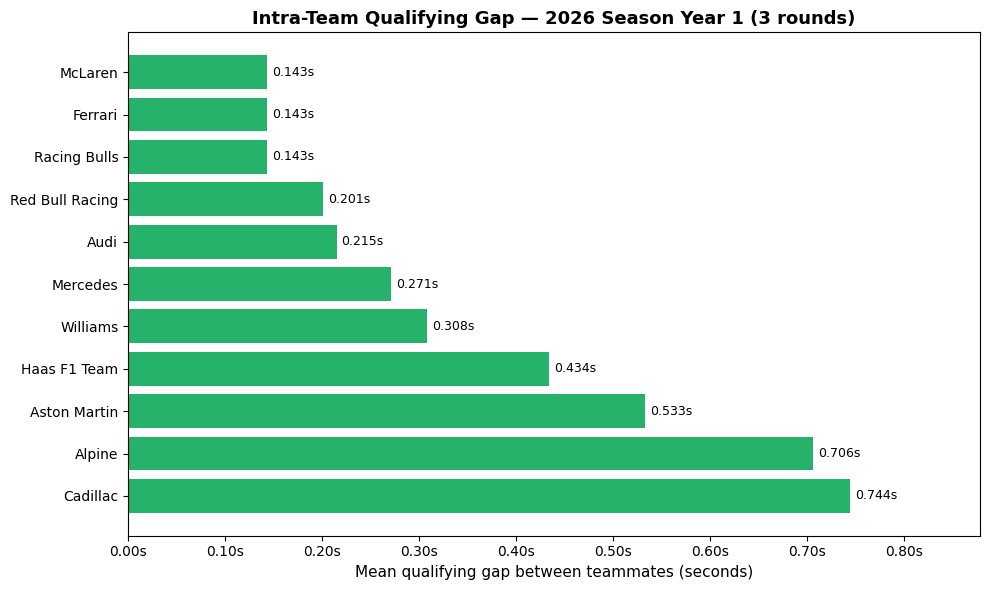

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
constructors = mean_2026['constructor'][::-1]
gaps = mean_2026['mean_gap_s'][::-1]

bars = ax.barh(constructors, gaps, color='#00A550', alpha=0.85)
ax.set_xlabel('Mean qualifying gap between teammates (seconds)', fontsize=11)
ax.set_title(f'Intra-Team Qualifying Gap — 2026 Season Year 1 ({len(quali_2026)} rounds)', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2fs'))

for bar, val in zip(bars, gaps):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}s', va='center', fontsize=9)

ax.set_xlim(0, gaps.max() * 1.18)
plt.tight_layout()
plt.show()

## 4. Driver Dominance — 2026 Year 1

In [12]:
dom_2026 = driver_dominance(gaps_2026, min_races=MIN_RACES)
dom_2026['season'] = 2026
print(dom_2026.to_string(index=False))

Empty DataFrame
Columns: [driver, constructor, total_races, faster_count, win_pct, season]
Index: []


## 5. Era Year 1 Comparison — Field-Wide Mean Gap

How tight were teammate pairs across the whole field in Year 1 of each regulation era?  
A smaller field-wide mean gap = more evenly matched teammates = potentially more competitive intra-team battles.

In [13]:
# Field-wide mean gap per era
field_summary = pd.DataFrame([
    {
        'season': 2022,
        'era': 'Ground Effect (2022)',
        'rounds': gaps_2022['round'].nunique(),
        'pairs': len(gaps_2022),
        'field_mean_gap_s': gaps_2022['gap_s'].mean().round(3),
        'field_median_gap_s': gaps_2022['gap_s'].median().round(3),
    },
    {
        'season': 2026,
        'era': f'2026 Era ({len(quali_2026)} rounds)',
        'rounds': gaps_2026['round'].nunique(),
        'pairs': len(gaps_2026),
        'field_mean_gap_s': gaps_2026['gap_s'].mean().round(3),
        'field_median_gap_s': gaps_2026['gap_s'].median().round(3),
    },
])
print(field_summary.to_string(index=False))

 season                  era  rounds  pairs  field_mean_gap_s  field_median_gap_s
   2022 Ground Effect (2022)      22    216             0.816               0.350
   2026  2026 Era (3 rounds)       3     30             0.349               0.276


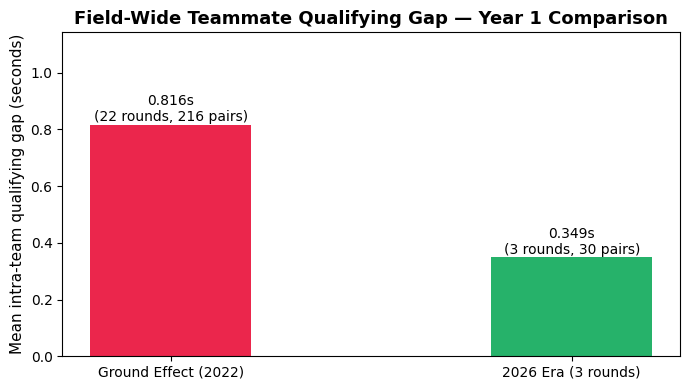

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
colours = ['#E8002D', '#00A550']
bars = ax.bar(field_summary['era'], field_summary['field_mean_gap_s'], color=colours, alpha=0.85, width=0.4)

for bar, (_, row) in zip(bars, field_summary.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f"{row['field_mean_gap_s']:.3f}s\n({row['rounds']} rounds, {row['pairs']} pairs)",
            ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Mean intra-team qualifying gap (seconds)', fontsize=11)
ax.set_title('Field-Wide Teammate Qualifying Gap — Year 1 Comparison', fontsize=13, fontweight='bold')
ax.set_ylim(0, field_summary['field_mean_gap_s'].max() * 1.4)
plt.tight_layout()
plt.show()

## 6. Gap Distribution — 2022 vs 2026 Year 1

Boxplot of per-race teammate gaps. Shows spread and outliers, not just the mean.

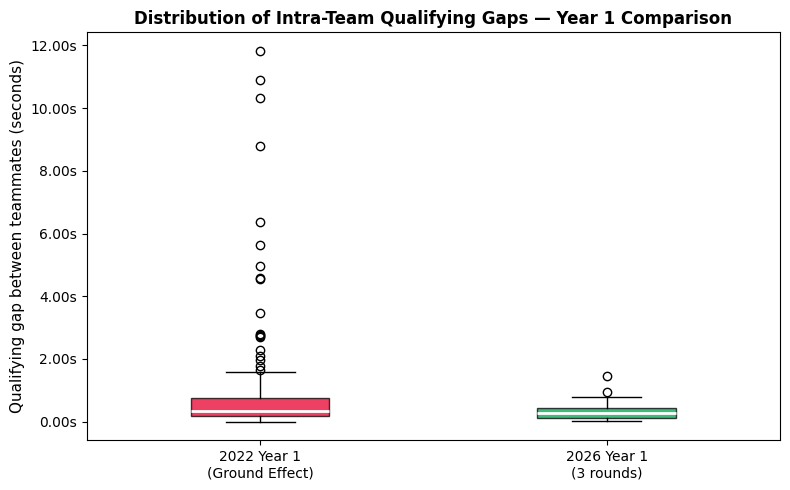

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

data = [gaps_2022['gap_s'].values, gaps_2026['gap_s'].values]
labels = ['2022 Year 1\n(Ground Effect)', f'2026 Year 1\n({len(quali_2026)} rounds)']
colours = ['#E8002D', '#00A550']

bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.4,
                medianprops={'color': 'white', 'linewidth': 2})
for patch, colour in zip(bp['boxes'], colours):
    patch.set_facecolor(colour)
    patch.set_alpha(0.75)

ax.set_ylabel('Qualifying gap between teammates (seconds)', fontsize=11)
ax.set_title('Distribution of Intra-Team Qualifying Gaps — Year 1 Comparison', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2fs'))
plt.tight_layout()
plt.show()

In [ ]:
# --- Summary table (auto-populated from field_summary computed above) ---
row_2022 = field_summary[field_summary['season'] == 2022].iloc[0]
row_2026 = field_summary[field_summary['season'] == 2026].iloc[0]

print("=" * 52)
print(f"{'Metric':<28} {'2022 Y1':>10} {'2026 Y1':>10}")
print("-" * 52)
print(f"{'Rounds loaded':<28} {int(row_2022['rounds']):>10} {int(row_2026['rounds']):>10}")
print(f"{'Field mean gap (s)':<28} {row_2022['field_mean_gap_s']:>10.3f} {row_2026['field_mean_gap_s']:>10.3f}")
print(f"{'Field median gap (s)':<28} {row_2022['field_median_gap_s']:>10.3f} {row_2026['field_median_gap_s']:>10.3f}")
print("=" * 52)
print(f"Note: 2026 data covers {int(row_2026['rounds'])} rounds — directional only.")

## 7. Constructor Like-for-Like — 2022 vs 2026

For teams that competed in both eras, compare how close their teammates were in Year 1 of each era.  
Note: constructor name mapping may be needed where teams rebranded between eras.

In [16]:
# Normalise constructor names for cross-era comparison.
# Extend this mapping as needed when more 2026 data arrives.
CONSTRUCTOR_MAP = {
    'Alfa Romeo': 'Kick Sauber',     # Sauber rebrand
    'AlphaTauri': 'Racing Bulls',    # VCARB rebrand
}

def normalise_constructor(name: str) -> str:
    return CONSTRUCTOR_MAP.get(name, name)

m2022 = mean_gap_by_constructor(gaps_2022).copy()
m2022['constructor_norm'] = m2022['constructor'].apply(normalise_constructor)
m2022['season'] = 2022

m2026 = mean_gap_by_constructor(gaps_2026).copy()
m2026['constructor_norm'] = m2026['constructor'].apply(normalise_constructor)
m2026['season'] = 2026

# Merge on normalised name
like_for_like = m2022.merge(
    m2026[['constructor_norm', 'mean_gap_s', 'races']],
    on='constructor_norm', suffixes=('_2022', '_2026'), how='inner'
)
like_for_like['gap_delta_s'] = (like_for_like['mean_gap_s_2026'] - like_for_like['mean_gap_s_2022']).round(3)
like_for_like = like_for_like.sort_values('gap_delta_s')

print(like_for_like[['constructor_norm', 'mean_gap_s_2022', 'mean_gap_s_2026', 'gap_delta_s']].to_string(index=False))

constructor_norm  mean_gap_s_2022  mean_gap_s_2026  gap_delta_s
         McLaren            1.218            0.143       -1.075
 Red Bull Racing            1.049            0.201       -0.848
        Williams            1.128            0.308       -0.820
         Ferrari            0.697            0.143       -0.554
    Racing Bulls            0.681            0.143       -0.538
    Haas F1 Team            0.777            0.434       -0.343
        Mercedes            0.467            0.271       -0.196
          Alpine            0.746            0.706       -0.040
    Aston Martin            0.539            0.533       -0.006


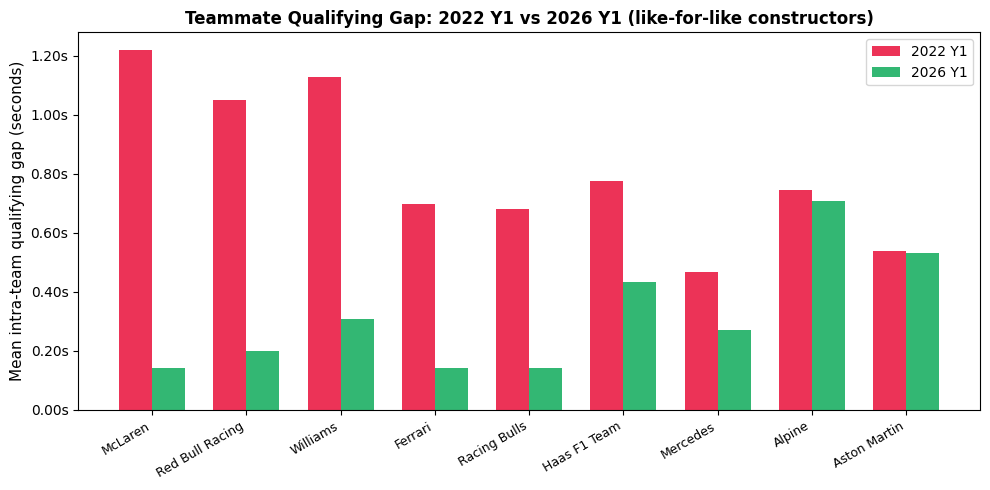

In [17]:
if not like_for_like.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    x = range(len(like_for_like))
    width = 0.35

    ax.bar([i - width/2 for i in x], like_for_like['mean_gap_s_2022'], width, label='2022 Y1', color='#E8002D', alpha=0.8)
    ax.bar([i + width/2 for i in x], like_for_like['mean_gap_s_2026'], width, label='2026 Y1', color='#00A550', alpha=0.8)

    ax.set_xticks(list(x))
    ax.set_xticklabels(like_for_like['constructor_norm'], rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Mean intra-team qualifying gap (seconds)', fontsize=11)
    ax.set_title('Teammate Qualifying Gap: 2022 Y1 vs 2026 Y1 (like-for-like constructors)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2fs'))
    plt.tight_layout()
    plt.show()
else:
    print('No like-for-like constructor matches found — check constructor name mapping.')

---
## Summary

| Metric | 2022 Y1 | 2026 Y1 |
|--------|---------|---------|
| Rounds loaded | 22 | 3 |
| Field mean gap (s) | 0.816 | 0.349 |
| Field median gap (s) | 0.350 | 0.276 |

2026 figures are directional — 3 rounds only (Australia, China, Japan). Re-run as the season progresses; the code cell above will update automatically.

### Next steps (v0.4.0 continued)
- Sector time breakdown by team/driver (FastF1 `sector_times`)
- Tyre compound strategy: stint lengths and compound choice by team
- Quali-to-race pace delta: does the faster qualifier also have better race pace?
- Re-run after Miami and each subsequent 2026 round to mature the intra-team picture

---
## Load Race Results

Loads race results for both seasons — used for quali-to-race pace delta.
Results are lightweight (driver/position/status per race, no lap data).

In [18]:
def load_season_race_results(year: int, rounds: list[int]) -> list:
    """Load FastF1 race session results for each round. Returns list of DataFrames."""
    results = []
    schedule = get_event_schedule(year)
    round_names = {
        int(row['RoundNumber']): row['EventName']
        for _, row in schedule.iterrows()
        if int(row['RoundNumber']) in rounds
    }
    for round_num in rounds:
        race_name = round_names.get(round_num, f'Round {round_num}')
        try:
            session = load_session(year, round_num, 'R')
            res = session.results.copy()
            res['season'] = year
            res['round'] = round_num
            res['race_name'] = race_name
            results.append(res)
            print(f'  {year} R{round_num:02d} {race_name}: {len(res)} drivers')
        except Exception as e:
            print(f'  {year} R{round_num:02d} {race_name}: SKIPPED ({e})')
    return results

print('Loading 2022 race results...')
race_results_2022 = load_season_race_results(2022, list(range(1, 23)))
print(f'Loaded {len(race_results_2022)} rounds.\n')

print('Loading 2026 race results...')
race_results_2026 = load_season_race_results(2026, [1, 2, 3])
print(f'Loaded {len(race_results_2026)} rounds.')

Loading 2022 race results...


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 16 completed the race distance 00:00.050000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '55', '44', '63', '20', '77', '31', '22', '14', '24', '47', 

  2022 R01 Bahrain Grand Prix: 20 drivers


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 22
core        WARNING 	No lap data for driver 47
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 22)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 47)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '55', '11', '63', '31', '4', '10', '20', '44', '24', 

  2022 R02 Saudi Arabian Grand Prix: 20 drivers


...

  2026 R01 Australian Grand Prix: 22 drivers


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 12 completed the race distance 00:00.022000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '63', '44', '16', '87', '10', '30', '6', '55', '43', '27', '41', '77', '31', '11', '3', '14', '18', '81', '1', '5', '23']
core           INFO 	Loading data for Japanese Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for sessi

  2026 R02 Chinese Grand Prix: 22 drivers


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '81', '16', '63', '1', '44', '10', '3', '30', '31', '27', '6', '5', '41', '55', '43', '11', '14', '77', '23', '18', '87']


  2026 R03 Japanese Grand Prix: 22 drivers
Loaded 3 rounds.


## 8. Quali-to-Race Pace Delta

Who converts qualifying position into race finishing position, and who doesn't?  
Positive mean delta = driver typically *gained* places in the race.  
DNFs excluded from the delta calculation.

**2022 Y1 vs 2026 Y1 — constructor mean delta.**

In [19]:
from src.analysis.quali_race_delta import quali_race_delta, mean_delta_by_constructor

def build_combined_results(results_list: list, year: int) -> pd.DataFrame:
    rows = []
    for res in results_list:
        season = year
        round_num = int(res['round'].iloc[0]) if 'round' in res.columns else None
        race_name = res['race_name'].iloc[0] if 'race_name' in res.columns else ''
        for _, r in res.iterrows():
            rows.append({
                'season': season,
                'round': round_num,
                'race_name': race_name,
                'driver_id': r.get('Abbreviation'),
                'driver_name': str(r.get('FullName', r.get('Abbreviation', ''))),
                'constructor_id': r.get('TeamName'),
                'grid_position': r.get('GridPosition'),
                'finish_position': r.get('Position'),
                'status': str(r.get('Status', '')),
            })
    return pd.DataFrame(rows)

res_2022 = build_combined_results(race_results_2022, 2022)
res_2026 = build_combined_results(race_results_2026, 2026)

delta_2022 = quali_race_delta(res_2022)
delta_2026 = quali_race_delta(res_2026)

con_delta_2022 = mean_delta_by_constructor(delta_2022)
con_delta_2026 = mean_delta_by_constructor(delta_2026)

print('2022 Y1 — Mean position delta by constructor (positive = gained places):')
print(con_delta_2022.to_string(index=False))
print()
print('2026 Y1 — Mean position delta by constructor (positive = gained places):')
print(con_delta_2026.to_string(index=False))

2022 Y1 — Mean position delta by constructor (positive = gained places):
 constructor_id  races  mean_delta  dnf_count
   Aston Martin     38        3.16          6
       Williams     34        2.06         10
         Alpine     36        2.03          8
       Mercedes     41        1.44          3
Red Bull Racing     39        1.38          5
        Ferrari     35        1.26          9
     Alfa Romeo     33        0.45         11
        McLaren     39        0.21          5
   Haas F1 Team     36        0.00          8
     AlphaTauri     35       -0.86          9

2026 Y1 — Mean position delta by constructor (positive = gained places):
 constructor_id  races  mean_delta  dnf_count
   Aston Martin      2        4.00          4
Red Bull Racing      4        3.50          2
       Cadillac      5        3.40          1
       Williams      5        3.00          1
   Haas F1 Team      5        2.60          1
         Alpine      6        1.33          0
   Racing Bulls      6   

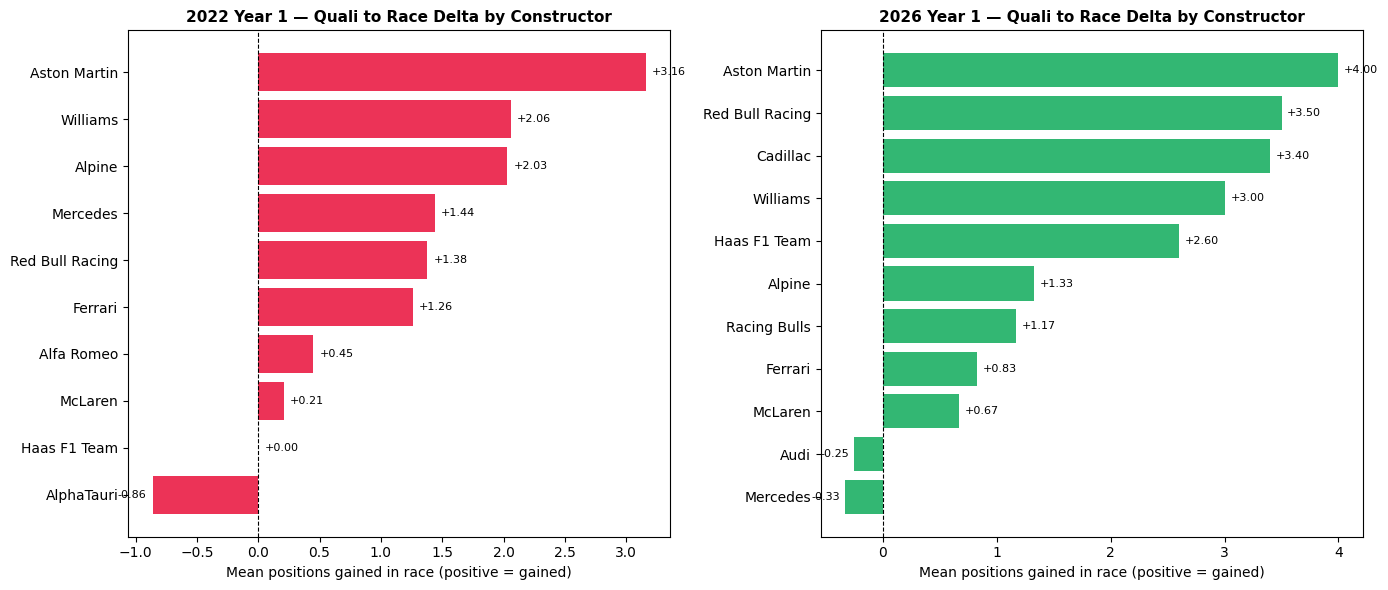

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

for ax, df, year, colour in zip(
    axes,
    [con_delta_2022, con_delta_2026],
    [2022, 2026],
    ['#E8002D', '#00A550'],
):
    df_plot = df.sort_values('mean_delta')
    bars = ax.barh(df_plot['constructor_id'], df_plot['mean_delta'], color=colour, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Mean positions gained in race (positive = gained)', fontsize=10)
    ax.set_title(f'{year} Year 1 — Quali to Race Delta by Constructor', fontsize=11, fontweight='bold')
    for bar, val in zip(bars, df_plot['mean_delta']):
        x_pos = val + 0.05 if val >= 0 else val - 0.05
        ha = 'left' if val >= 0 else 'right'
        ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
                f'{val:+.2f}', va='center', ha=ha, fontsize=8)

plt.tight_layout()
plt.show()

---
## Load Race Laps

Loads full lap data — required for sector times, tyre strategy, field normalisation, tail-of-field, and pit window analyses.

**This is the heaviest data load.** First run downloads from FastF1 and populates the cache; subsequent runs read locally. For 22 rounds of 2022 data expect several minutes on first run.

In [21]:
def load_season_race_laps(year: int, rounds: list[int]) -> dict:
    """Load race lap DataFrames for specified rounds. Returns {(year, round): laps_df}."""
    season_laps = {}
    schedule = get_event_schedule(year)
    round_names = {
        int(row['RoundNumber']): row['EventName']
        for _, row in schedule.iterrows()
        if int(row['RoundNumber']) in rounds
    }
    for round_num in rounds:
        race_name = round_names.get(round_num, f'Round {round_num}')
        try:
            session = load_session(year, round_num, 'R')
            season_laps[(year, round_num)] = session.laps.copy()
            print(f'  {year} R{round_num:02d} {race_name}: {len(session.laps)} laps')
        except Exception as e:
            print(f'  {year} R{round_num:02d} {race_name}: SKIPPED ({e})')
    return season_laps

print('Loading 2022 Y1 race laps (rounds 1-22)...')
race_laps_2022 = load_season_race_laps(2022, list(range(1, 23)))
print(f'Loaded {len(race_laps_2022)} rounds.\n')

print('Loading 2026 Y1 race laps (rounds 1-3)...')
race_laps_2026 = load_season_race_laps(2026, [1, 2, 3])
print(f'Loaded {len(race_laps_2026)} rounds.')

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Loading 2022 Y1 race laps (rounds 1-22)...


core        WARNING 	Driver 16 completed the race distance 00:00.050000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '55', '44', '63', '20', '77', '31', '22', '14', '24', '47', '18', '23', '3', '4', '6', '27', '11', '1', '10']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_

  2022 R01 Bahrain Grand Prix: 1125 laps


core        WARNING 	No lap data for driver 22
core        WARNING 	No lap data for driver 47
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 22)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 47)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '55', '11', '63', '31', '4', '10', '20', '44', '24', '27', '18', '23', '77', '14', '3', '6', '22', '47']
core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap

...

  2026 R01 Australian Grand Prix: 1007 laps


core        WARNING 	Driver 12 completed the race distance 00:00.022000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '63', '44', '16', '87', '10', '30', '6', '55', '43', '27', '41', '77', '31', '11', '3', '14', '18', '81', '1', '5', '23']
core           INFO 	Loading data for Japanese Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for 

  2026 R02 Chinese Grand Prix: 924 laps


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '81', '16', '63', '1', '44', '10', '3', '30', '31', '27', '6', '5', '41', '55', '43', '11', '14', '77', '23', '18', '87']


  2026 R03 Japanese Grand Prix: 1107 laps
Loaded 3 rounds.


## 9. Sector Time Breakdown

P1-P10 gap per sector — which part of the track separates the field most?  
Each sector is ranked independently (not a single combined lap gap).  
Pit-in/out and inaccurate laps excluded.

A consistently large sector gap indicates where car characteristics spread the field.

In [22]:
from src.analysis.sector_times import sector_gap_summary, mean_sector_gap_by_season

sector_summary_2022 = sector_gap_summary(race_laps_2022)
sector_summary_2026 = sector_gap_summary(race_laps_2026)

mean_sector_2022 = mean_sector_gap_by_season(sector_summary_2022)
mean_sector_2026 = mean_sector_gap_by_season(sector_summary_2026)

print('Mean P1-P10 sector gap (seconds) - Year 1 comparison:')
print('2022 Y1:', mean_sector_2022[['mean_s1_gap_s', 'mean_s2_gap_s', 'mean_s3_gap_s', 'races']].to_string(index=False))
print('2026 Y1:', mean_sector_2026[['mean_s1_gap_s', 'mean_s2_gap_s', 'mean_s3_gap_s', 'races']].to_string(index=False))

Mean P1-P10 sector gap (seconds) - Year 1 comparison:
2022 Y1:  mean_s1_gap_s  mean_s2_gap_s  mean_s3_gap_s  races
         0.599          0.924          0.722     22
2026 Y1:  mean_s1_gap_s  mean_s2_gap_s  mean_s3_gap_s  races
         0.503          0.518          0.551      3


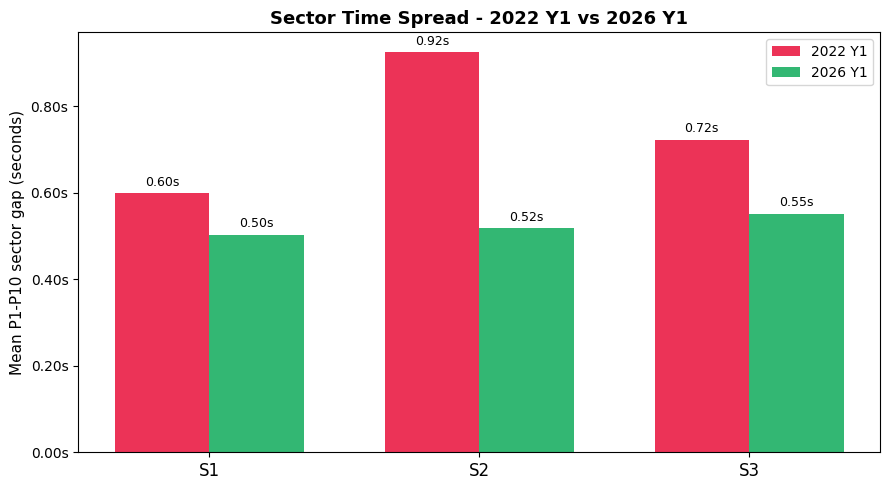

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))

sectors = ['S1', 'S2', 'S3']
x = range(len(sectors))
width = 0.35

for i, (df, year, colour) in enumerate([
    (mean_sector_2022, 2022, '#E8002D'),
    (mean_sector_2026, 2026, '#00A550'),
]):
    if df.empty:
        continue
    row = df.iloc[0]
    gaps = [row['mean_s1_gap_s'], row['mean_s2_gap_s'], row['mean_s3_gap_s']]
    offset = width * (i - 0.5)
    bars = ax.bar([xi + offset for xi in x], gaps, width, label=f'{year} Y1', color=colour, alpha=0.8)
    for bar, val in zip(bars, gaps):
        if val is not None:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{val:.2f}s', ha='center', va='bottom', fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(sectors, fontsize=12)
ax.set_ylabel('Mean P1-P10 sector gap (seconds)', fontsize=11)
ax.set_title('Sector Time Spread - 2022 Y1 vs 2026 Y1', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2fs'))
plt.tight_layout()
plt.show()

## 10. Tyre Compound Strategy

Which compounds do teams choose, and how long do they run them?  
Pit-in and pit-out laps excluded from stint length counts.  
UNKNOWN compound laps (FastF1 artefact at session start) are excluded.

In [24]:
from src.analysis.tyre_strategy import compound_usage_by_constructor, mean_stint_length

all_laps_2022 = pd.concat(race_laps_2022.values(), ignore_index=True)
all_laps_2026 = pd.concat(race_laps_2026.values(), ignore_index=True)

stint_len_2022 = mean_stint_length(all_laps_2022)
stint_len_2022['season'] = 2022
stint_len_2026 = mean_stint_length(all_laps_2026)
stint_len_2026['season'] = 2026

print('Mean stint length by compound - 2022 Y1:')
print(stint_len_2022[['compound', 'mean_laps', 'stints']].to_string(index=False))
print()
print('Mean stint length by compound - 2026 Y1:')
print(stint_len_2026[['compound', 'mean_laps', 'stints']].to_string(index=False))

Mean stint length by compound - 2022 Y1:
    compound  mean_laps  stints
        HARD      119.9      67
INTERMEDIATE       26.3      55
      MEDIUM      124.4      74
        None       25.7      13
        SOFT       44.5      94
         WET        9.9      38

Mean stint length by compound - 2026 Y1:
compound  mean_laps  stints
    HARD       53.6      36
  MEDIUM       28.0      34
    SOFT        8.6      18


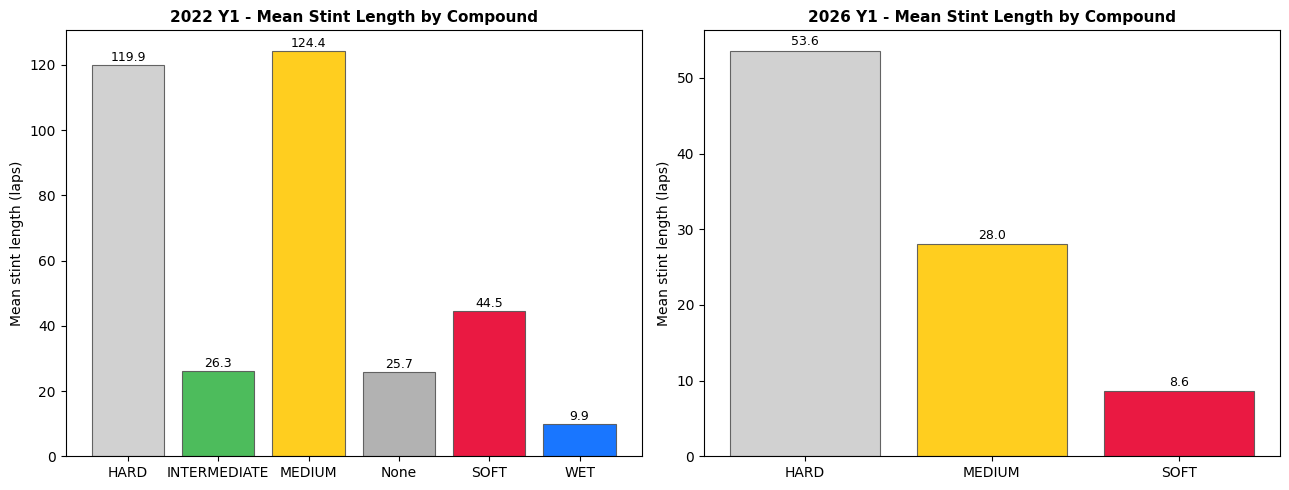

In [25]:
COMPOUND_COLOURS = {
    'SOFT': '#E8002D', 'MEDIUM': '#FFC906', 'HARD': '#CCCCCC',
    'INTERMEDIATE': '#39B54A', 'WET': '#0067FF',
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, year in zip(axes, [stint_len_2022, stint_len_2026], [2022, 2026]):
    if df.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        continue
    compounds = df['compound'].tolist()
    lengths = df['mean_laps'].tolist()
    colours = [COMPOUND_COLOURS.get(c, '#AAAAAA') for c in compounds]
    bars = ax.bar(compounds, lengths, color=colours, edgecolor='#555555', linewidth=0.8, alpha=0.9)
    for bar, val in zip(bars, lengths):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('Mean stint length (laps)', fontsize=10)
    ax.set_title(f'{year} Y1 - Mean Stint Length by Compound', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 11. Field Size Normalisation and Points Boundary

### 11a. Field Normalisation
The standard P1-P10 gap silently excludes attrition races (fewer than 10 finishers).  
The normalised view emits a row for every race — attrition races are flagged rather than quietly removed from the average.

### 11b. P10/P11 Boundary
How arbitrary is the points cut? A small P10-P11 lap time gap means the boundary was razor-thin on pure pace.

In [26]:
from src.analysis.field_spread import p1_to_pn_gap_normalised, p11_gap_per_race

norm_2022 = p1_to_pn_gap_normalised(race_laps_2022, n=10)
norm_2026 = p1_to_pn_gap_normalised(race_laps_2026, n=10)

attrition_2022 = norm_2022[~norm_2022['sufficient']]
print(f'2022 Y1: {len(attrition_2022)} rounds with fewer than 10 drivers with valid laps:')
if attrition_2022.empty:
    print('  None')
else:
    print(attrition_2022[['season', 'round', 'drivers_with_laps']].to_string(index=False))
print()

p11_2022 = p11_gap_per_race(race_laps_2022)
p11_2026 = p11_gap_per_race(race_laps_2026)

print(f'2022 Y1 - mean P10-P11 gap: {p11_2022["p10_p11_gap_s"].mean():.3f}s  '
      f'(median: {p11_2022["p10_p11_gap_s"].median():.3f}s) across {len(p11_2022)} races')
print(f'2026 Y1 - mean P10-P11 gap: {p11_2026["p10_p11_gap_s"].mean():.3f}s  '
      f'(median: {p11_2026["p10_p11_gap_s"].median():.3f}s) across {len(p11_2026)} races')
print('Note: lap-time gap is a pace proxy, not the finish time gap.')

2022 Y1: 0 rounds with fewer than 10 drivers with valid laps:
  None

2022 Y1 - mean P10-P11 gap: 0.135s  (median: 0.100s) across 22 races
2026 Y1 - mean P10-P11 gap: 0.202s  (median: 0.237s) across 3 races
Note: lap-time gap is a pace proxy, not the finish time gap.


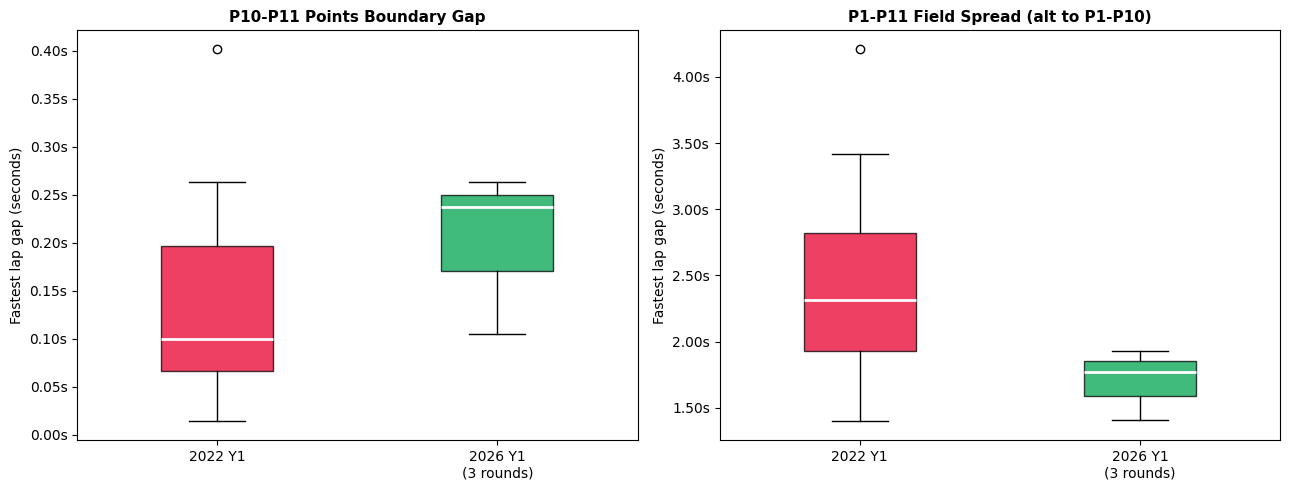

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in zip(
    axes,
    ['p10_p11_gap_s', 'p1_p11_gap_s'],
    ['P10-P11 Points Boundary Gap', 'P1-P11 Field Spread (alt to P1-P10)'],
):
    data = [p11_2022[col].values, p11_2026[col].values]
    labels = ['2022 Y1', f'2026 Y1\n({len(p11_2026)} rounds)']
    bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.4,
                    medianprops={'color': 'white', 'linewidth': 2})
    for patch, colour in zip(bp['boxes'], ['#E8002D', '#00A550']):
        patch.set_facecolor(colour)
        patch.set_alpha(0.75)
    ax.set_ylabel('Fastest lap gap (seconds)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2fs'))

plt.tight_layout()
plt.show()

## 12. Tail-of-Field Gap

How far behind is the back of the grid?  
Uses fastest race lap as the pace proxy — only drivers who set at least one valid lap are included.  
Regulation reset years may stretch the tail as backmarker teams struggle to keep pace with the new rules.

In [28]:
from src.analysis.field_spread import tail_gap_analysis

tail_2022 = tail_gap_analysis(race_laps_2022)
tail_2026 = tail_gap_analysis(race_laps_2026)

print(f'2022 Y1 - mean tail-to-P1 gap:  {tail_2022["tail_to_p1_gap_s"].mean():.2f}s  '
      f'mean tail-to-P10 gap: {tail_2022["tail_to_p10_gap_s"].mean():.2f}s')
print(f'2026 Y1 - mean tail-to-P1 gap:  {tail_2026["tail_to_p1_gap_s"].mean():.2f}s  '
      f'mean tail-to-P10 gap: {tail_2026["tail_to_p10_gap_s"].mean():.2f}s  (directional, 3 rounds)')

2022 Y1 - mean tail-to-P1 gap:  6.08s  mean tail-to-P10 gap: 3.81s
2026 Y1 - mean tail-to-P1 gap:  5.22s  mean tail-to-P10 gap: 3.72s  (directional, 3 rounds)


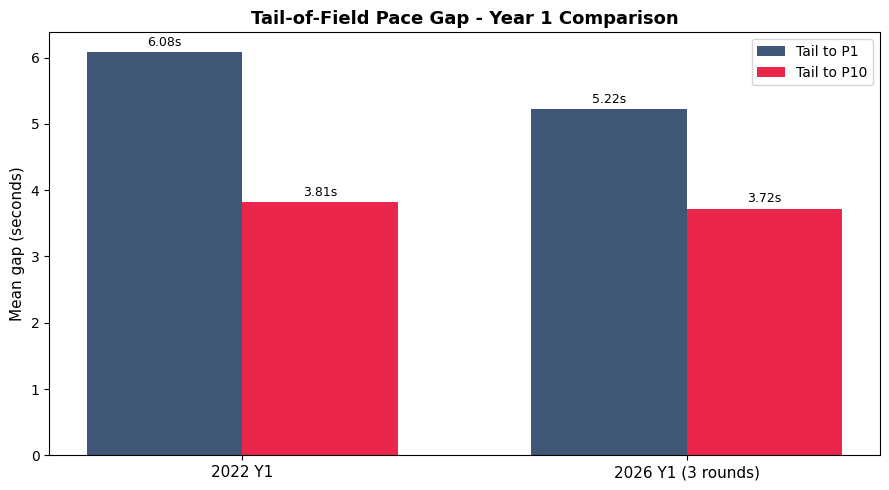

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))

labels = ['2022 Y1', f'2026 Y1 ({len(tail_2026)} rounds)']
tail_p1 = [tail_2022['tail_to_p1_gap_s'].mean(), tail_2026['tail_to_p1_gap_s'].mean()]
tail_p10 = [tail_2022['tail_to_p10_gap_s'].mean(), tail_2026['tail_to_p10_gap_s'].mean()]
x = range(len(labels))
width = 0.35
ax.bar([xi - width/2 for xi in x], tail_p1, width, label='Tail to P1', color='#1E3A5F', alpha=0.85)
ax.bar([xi + width/2 for xi in x], tail_p10, width, label='Tail to P10', color='#E8002D', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Mean gap (seconds)', fontsize=11)
ax.set_title('Tail-of-Field Pace Gap - Year 1 Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
for xi, (p1, p10) in enumerate(zip(tail_p1, tail_p10)):
    ax.text(xi - width/2, p1 + 0.1, f'{p1:.2f}s', ha='center', fontsize=9)
    ax.text(xi + width/2, p10 + 0.1, f'{p10:.2f}s', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 13. Sprint Race Analysis

Sprint weekends provide a pit-stop-free baseline — most cars complete the sprint on their starting tyres, isolating pure pace from strategy.

**2022 sprint weekends:** Emilia Romagna (R4), Austria (R11), Brazil (R22).  
**2026 sprint weekends:** China (R2).

Comparing sprint vs full race median lap pace isolates the strategy and tyre degradation effect.

In [30]:
from src.analysis.sprint_analysis import sprint_vs_race_pace

SPRINT_ROUNDS_2022 = [4, 11, 22]  # Emilia Romagna, Austria, Brazil
SPRINT_ROUNDS_2026 = [2]          # China

def load_sprint_weekend(year: int, round_num: int):
    try:
        sprint_session = load_session(year, round_num, 'S')
        race_session = load_session(year, round_num, 'R')
        return sprint_session.laps.copy(), race_session.laps.copy()
    except Exception as e:
        print(f'  {year} R{round_num:02d}: SKIPPED ({e})')
        return None, None

print('Loading sprint weekend data...')
pace_comparisons = []
for year, sprint_rounds in [(2022, SPRINT_ROUNDS_2022), (2026, SPRINT_ROUNDS_2026)]:
    for rnd in sprint_rounds:
        s_laps, r_laps = load_sprint_weekend(year, rnd)
        if s_laps is not None:
            comp = sprint_vs_race_pace(s_laps, r_laps)
            comp['season'] = year
            comp['round'] = rnd
            pace_comparisons.append(comp)
            med_sprint = comp['sprint_median_s'].mean()
            med_race = comp['race_median_s'].mean()
            print(f'  {year} R{rnd:02d}: sprint median {med_sprint:.2f}s vs race median {med_race:.2f}s '
                  f'(+{med_race - med_sprint:.2f}s in race)')

if pace_comparisons:
    sprint_pace_df = pd.concat(pace_comparisons, ignore_index=True)
    summary = sprint_pace_df.groupby(['season', 'round'])['delta_s'].agg(
        mean_delta='mean', drivers='count'
    ).reset_index()
    print('\nField-wide mean pace delta (race slower than sprint by, seconds):')
    print(summary.to_string(index=False))

core           INFO 	Loading data for Emilia Romagna Grand Prix - Sprint [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


Loading sprint weekend data...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

  2022 R04: sprint median 81.01s vs race median 83.00s (+1.98s in race)


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

  2022 R11: sprint median 70.36s vs race median 71.28s (+0.92s in race)
  2022 R22: SKIPPED (Session type 'S' does not exist for this event)


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

  2026 R02: sprint median 98.95s vs race median 98.29s (+-0.66s in race)

Field-wide mean pace delta (race slower than sprint by, seconds):
 season  round  mean_delta  drivers
   2022      4    1.981333       18
   2022     11    0.920526       19
   2026      2   -0.659500       18


## 14. Pre vs Post Pit Window

**Hypothesis:** The first phase of a Grand Prix (before the main pit window)
is more competitive than the post-stop phase, where fresh tyres spread the field.

Metric: mean per-lap P1-P3 gap before and after the median pit lap.  
P1-P3 (not P1-P10) is used to remain robust across attrition-heavy fields  
and SC periods where stricter filtering would remove too many laps.  
Points above the diagonal = field widened post-pit (hypothesis confirmed for that race).

In [31]:
from src.analysis.pit_window import pit_window_summary

pit_summary_2022 = pit_window_summary(race_laps_2022)
pit_summary_2026 = pit_window_summary(race_laps_2026)

for year, df in [(2022, pit_summary_2022), (2026, pit_summary_2026)]:
    valid = df.dropna(subset=['pre_mean_gap_s', 'post_mean_gap_s'])
    if valid.empty:
        print(f'{year} Y1: no races with both pre and post phase data')
        continue
    mean_pre = valid['pre_mean_gap_s'].mean()
    mean_post = valid['post_mean_gap_s'].mean()
    pct_wider = (valid['post_mean_gap_s'] > valid['pre_mean_gap_s']).mean() * 100
    print(f'{year} Y1 ({len(valid)} races):')
    print(f'  Pre-pit  mean P1-P5 gap: {mean_pre:.3f}s')
    print(f'  Post-pit mean P1-P5 gap: {mean_post:.3f}s')
    print(f'  Field wider post-pit: {pct_wider:.0f}% of races')
    print()

2022 Y1: no races with both pre and post phase data
2026 Y1: no races with both pre and post phase data


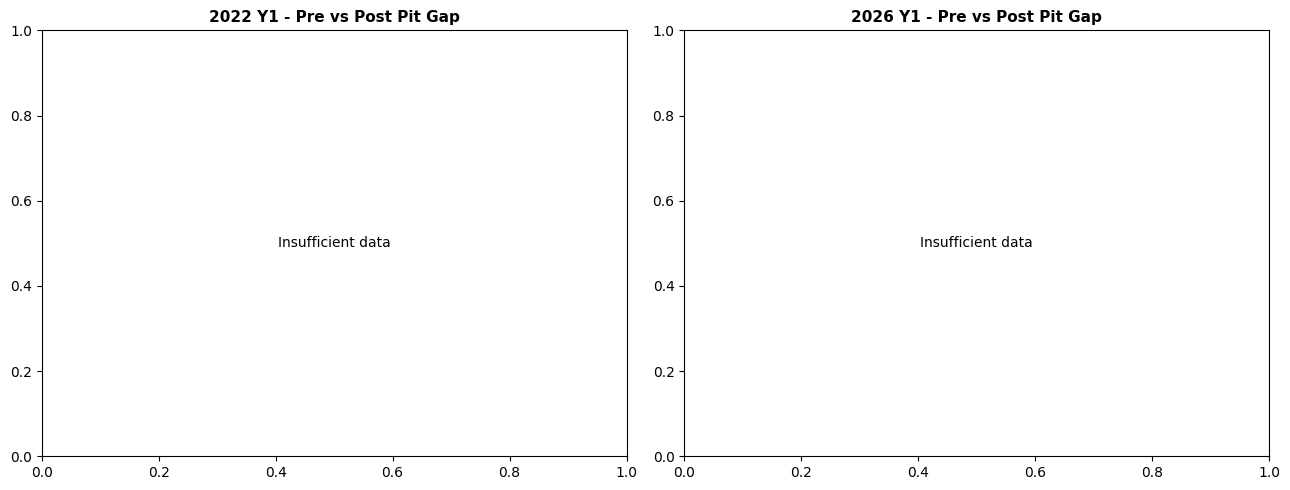

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, year, colour in zip(
    axes,
    [pit_summary_2022, pit_summary_2026],
    [2022, 2026],
    ['#E8002D', '#00A550'],
):
    valid = df.dropna(subset=['pre_mean_gap_s', 'post_mean_gap_s'])
    if valid.empty:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{year} Y1 - Pre vs Post Pit Gap', fontsize=11, fontweight='bold')
        continue
    ax.scatter(valid['pre_mean_gap_s'], valid['post_mean_gap_s'],
               color=colour, alpha=0.7, s=60, zorder=3)
    max_val = max(valid['pre_mean_gap_s'].max(), valid['post_mean_gap_s'].max()) * 1.1
    ax.plot([0, max_val], [0, max_val], 'k--', linewidth=0.8, label='No change')
    ax.set_xlabel('Pre-pit P1-P5 gap (s)', fontsize=10)
    ax.set_ylabel('Post-pit P1-P5 gap (s)', fontsize=10)
    ax.set_title(f'{year} Y1 - Pre vs Post Pit Window Gap', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    above = (valid['post_mean_gap_s'] > valid['pre_mean_gap_s']).sum()
    ax.text(0.05, 0.95, f'Field wider post-pit: {above}/{len(valid)} races',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()